In [40]:
from langgraph.graph import StateGraph,START,END
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq
from typing import TypedDict
from langchain_core.output_parsers import StrOutputParser
from langchain_google_genai import ChatGoogleGenerativeAI

from dotenv import load_dotenv

In [26]:
load_dotenv()

True

# 1. Prompt Chaining 

## 1. BMI calculator

In [27]:
# Defining State

# 1. State Structure
class BMIState(TypedDict):
    weight:float
    height:float
    bmi:float
    category:str
    
# 2. State Creation

graph=StateGraph(state_schema=BMIState)

In [28]:
# Creating Node Functions

def bmi_calculator(state: BMIState):
    weight=state['weight']
    height=state['height']
    
    bmi=weight/(height**2)
    
    return {'bmi':bmi}


def bmi_categorizer(state: BMIState):
    bmi=state['bmi']
    
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [29]:
# Creating Graph

# 1. Initilize Nodes
graph.add_node('bmi_calculator',bmi_calculator)
graph.add_node('bmi_categorizer',bmi_categorizer)

# 2. Add Edge
graph.add_edge(start_key=START,end_key='bmi_calculator')
graph.add_edge(start_key='bmi_calculator',end_key='bmi_categorizer')
graph.add_edge(start_key='bmi_categorizer',end_key=END)

# 3. Compile The Graph

workflow=graph.compile()

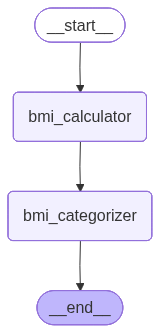

In [30]:
workflow

In [31]:
initial_state={'weight':80,'height':1.50}

final_state=workflow.invoke(initial_state)

In [32]:
final_state

{'weight': 80, 'height': 1.5, 'bmi': 35.55555555555556, 'category': 'Obese'}

## 2. Simple Chatbot

In [44]:
# 1. Define State and Graph

class ChatbotState(TypedDict):
    user_query:str
    llm_response: str
    
    
chatbot_graph=StateGraph(state_schema=ChatbotState)

In [45]:
parser=StrOutputParser()
model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

In [46]:
def chatbot(state: ChatbotState):
    user_query=state['user_query']
    
    prompt=PromptTemplate(
        template='Please answer the following query of the user query: {user_query}',
        input_variables=['user_query']
    )
    
    chain=prompt | model | parser
    
    response=chain.invoke({'user_query':user_query})
    return {'llm_response':response}
    
    

In [47]:
# add nodes and edge

chatbot_graph.add_node('chatbot',chatbot)


chatbot_graph.add_edge(start_key=START,end_key='chatbot')
chatbot_graph.add_edge(start_key='chatbot',end_key=END)

workflow=chatbot_graph.compile()


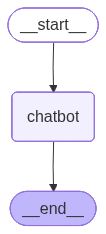

In [48]:
workflow

In [49]:
response=workflow.invoke({'user_query':'what is Generative AI'})

In [50]:
response

{'user_query': 'what is Generative AI',
 'llm_response': 'Generative AI refers to a type of artificial intelligence that can **create new, original content** such as text, images, music, code, and more. Unlike traditional AI that is designed to analyze or classify existing data, generative AI learns patterns and structures from vast datasets and then uses that knowledge to produce something entirely novel.\n\nHere\'s a breakdown of what that means:\n\n**Key Characteristics of Generative AI:**\n\n*   **Creation of New Content:** This is the defining feature. It doesn\'t just retrieve or modify existing information; it synthesizes new output.\n*   **Learning from Data:** Generative AI models are trained on enormous amounts of data. For example, a text-generating AI might be trained on billions of words from books, articles, and websites. An image-generating AI would be trained on millions of images.\n*   **Pattern Recognition and Synthesis:** During training, the AI identifies underlying

In [52]:
response['llm_response']

'Generative AI refers to a type of artificial intelligence that can **create new, original content** such as text, images, music, code, and more. Unlike traditional AI that is designed to analyze or classify existing data, generative AI learns patterns and structures from vast datasets and then uses that knowledge to produce something entirely novel.\n\nHere\'s a breakdown of what that means:\n\n**Key Characteristics of Generative AI:**\n\n*   **Creation of New Content:** This is the defining feature. It doesn\'t just retrieve or modify existing information; it synthesizes new output.\n*   **Learning from Data:** Generative AI models are trained on enormous amounts of data. For example, a text-generating AI might be trained on billions of words from books, articles, and websites. An image-generating AI would be trained on millions of images.\n*   **Pattern Recognition and Synthesis:** During training, the AI identifies underlying patterns, relationships, and styles within the data. It 

## 3. Blogger Chatbot

In [58]:
class BloggerState(TypedDict):
    blog_title: str
    outline: str
    content: str
    
blogger_graph=StateGraph(state_schema=BloggerState)

In [59]:
blogger_chat_model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
parser=StrOutputParser()

In [60]:
def outline_generator(state: BloggerState):
    blog_title=state['blog_title']
    
    prompt=PromptTemplate(
        template='For the following blog title create a outline of what all content should be added in the following blog title provided by the user. blog title: {blog_title}',
        input_variables=['blog_title']
    )
    
    chain=prompt | blogger_chat_model | parser
    
    outline=chain.invoke({'blog_title':blog_title})
    
    return {'outline':outline}


def content_generator(state: BloggerState):
    blog_title=state['blog_title']
    outline=state['outline']
    
    prompt=PromptTemplate(
        template='provided a Blog Title and outline which tells what all content should be in the blog. Write a Clean and Good Blog for the following title and content. blog title: {blog_title}',
        input_variables=['blog_title','outline']
    )
    
    chain=prompt | blogger_chat_model | parser
    
    content=chain.invoke({'blog_title':blog_title,'outline':outline})
    
    return {'content':content}

In [61]:
blogger_graph.add_node('outline_generator',outline_generator)
blogger_graph.add_node('content_generator',content_generator)

blogger_graph.add_edge(start_key=START,end_key='outline_generator')
blogger_graph.add_edge(start_key='outline_generator',end_key='content_generator')
blogger_graph.add_edge(start_key='content_generator',end_key=END)


workflow=blogger_graph.compile()

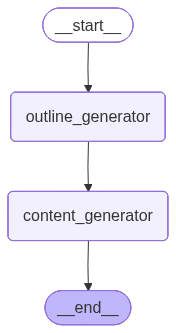

In [62]:
workflow

In [63]:
response=workflow.invoke({'blog_title':'Why GenAI is Trending these days'})

In [64]:
response

{'blog_title': 'Why GenAI is Trending these days',
 'outline': 'Here\'s a comprehensive outline for a blog post titled "Why GenAI is Trending These Days":\n\n## Blog Post Outline: Why GenAI is Trending These Days\n\n**I. Introduction: The Buzz Around GenAI**\n\n*   **Hook:** Start with a captivating statistic, a surprising example of GenAI in action, or a relatable anecdote about encountering GenAI recently.\n*   **What is GenAI?**\n    *   Brief, accessible definition (Generative Artificial Intelligence).\n    *   Distinguish it from traditional AI (predictive/analytical vs. creative/generative).\n    *   Mention key capabilities (text generation, image creation, code writing, music composition, etc.).\n*   **The "Trending" Aspect:**\n    *   Acknowledge the current surge in public awareness and discussion.\n    *   Briefly hint at the reasons for this trend that will be explored in the post.\n*   **Thesis Statement/Roadmap:** Clearly state what the blog post will cover (the key drive